# Model Training — FDA Adverse Event Signal Detector

This notebook trains and evaluates a classifier predicting whether an adverse event report is marked serious, using the cleaned, feature-engineered FDA dataset. It picks up directly from the findings in `eda.ipynb`, which found the target imbalanced (79% serious, 21% not serious), patient age weakly related to seriousness, and a meaningful, drug-dependent variation in serious-report rates across the 15 target drugs.

The baseline model is logistic regression, starting with numeric features (reaction_count, drug_count, patientonsetage_years, patientsex), with drug identity added as a richer feature set once the baseline pipeline is confirmed working. Given the class imbalance found in EDA, evaluation will use precision, recall, and a confusion matrix rather than accuracy alone.

In [ ]:
import pandas as pd
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [3]:
conn = sqlite3.connect("../data/fda_adverse_events.db")
df = pd.read_sql_query("SELECT * FROM reports", conn)

## Handling Missing Values

reaction_count and drug_count are complete for every report, but patientonsetage_years is missing for 4,089 reports and patientsex for 428. Rather than dropping this data, values will be filled in so the full dataset can be used for training. checking patientsex's existing coding scheme first, since "Unknown" (0) may already be a valid category rather than something to invent.

In [4]:
df[["reaction_count", "drug_count", "patientonsetage_years", "patientsex"]].isnull().sum()

reaction_count              0
drug_count                  0
patientonsetage_years    4089
patientsex                428
dtype: int64

In [6]:
df["patientsex"].value_counts(dropna=False)

patientsex
2      12892
1       9377
0        476
NaN      428
Name: count, dtype: int64

In [7]:
df["patientsex"].dtype

<StringDtype(na_value=nan)>

In [8]:
df["patientonsetage_years"] = df["patientonsetage_years"].fillna(df["patientonsetage_years"].median())
df["patientsex"] = df["patientsex"].fillna("0")

In [9]:
df[["reaction_count", "drug_count", "patientonsetage_years", "patientsex"]].isnull().sum()

reaction_count           0
drug_count               0
patientonsetage_years    0
patientsex               0
dtype: int64

## Building X and y

With missing values handled, building the feature matrix (X) and target (y) for the baseline model, using the full dataset of 23,173 reports.

In [11]:
X = df[["reaction_count", "drug_count", "patientonsetage_years", "patientsex"]]
y = (df["serious"] == "1").astype(int)

## Train/Test Split

Splitting the data into a training set (used to fit the model) and a held-out test set (used only to evaluate it afterward), so performance is measured on data the model has never seen. Given the class imbalance found in EDA (79% serious, 21% not serious), the split is stratified to preserve that same ratio in both the training and test sets.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
X_train.shape


(18538, 4)

In [16]:
X_test.shape

(4635, 4)

In [18]:
y_train.value_counts(normalize=True)

serious
1    0.790646
0    0.209354
Name: proportion, dtype: float64

In [19]:
y_test.value_counts(normalize=True)

serious
1    0.790723
0    0.209277
Name: proportion, dtype: float64

## Baseline Model: Logistic Regression

Training a logistic regression classifier on the training set, predicting whether a report is serious (1) or not (0) from the four baseline features.

In [33]:
model = LogisticRegression(class_weight="balanced")
model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

In [34]:
y_pred = model.predict(X_test)

In [35]:
print(model.coef_)
print(model.intercept_)

[[ 0.10224821  0.0317037  -0.00963779 -0.43496044]]
[0.66985441]


model.coef_ returns the learned weight for each feature, in the same order as X's columns.
model.intercept_ returns the bias term.

- reaction_count: +0.105 — positive, pushes toward "serious" as it increases.
- drug_count: +0.033 — positive, but a much weaker effect than reaction_count.
- patientonsetage_years: -0.009 — negligible, independently confirming the weak age-seriousness relationship found in the EDA.
- patientsex: -0.442 — the largest magnitude, though this should be interpreted cautiously.patientsex is an unordered category (0=Unknown, 1=Male, 2=Female), and feeding it into logistic regression as a plain number implicitly treats it as an ordered scale. One-hot encoding would be a more appropriate treatment for this feature, worth revisiting.
- intercept: 1.958 — the baseline pull toward "serious" before any feature adjustment, partly reflecting the dataset's overall 79% serious baseline

Notably, the model's own learned weights corroborate the EDA finding that age carries little predictive signal. Two independent methods (visual exploration and the model's fitted coefficients) agreeing on the same conclusion.

## Evaluating the Model

Generating predictions on the test set (data the model has never seen) and evaluating performance using precision, recall, and a confusion matrix, given the class imbalance found in EDA.

In [36]:
print(confusion_matrix(y_test, y_pred))

[[ 651  319]
 [1701 1964]]


In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.28      0.67      0.39       970
           1       0.86      0.54      0.66      3665

    accuracy                           0.56      4635
   macro avg       0.57      0.60      0.53      4635
weighted avg       0.74      0.56      0.60      4635



## Adjusting the Decision Threshold

The default 0.5 threshold treats a false positive and a false negative as equally costly, but for this project missing a genuinely serious report (false negative) is judged worse than a false alarm (false positive). 

Rather than accept the default cutoff, this section extracts the model's raw predicted probabilities and tests lower thresholds, deliberately trading precision for recall on the serious class.

In [39]:
y_proba_serious = model.predict_proba(X_test)[:, 1]
print(y_proba_serious)

[0.5103835  0.51468044 0.64719172 ... 0.49195249 0.45877133 0.36444601]


In [40]:
threshold = 0.3
y_pred_new_threshold = (y_proba_serious >= threshold).astype(int)

In [41]:
print(confusion_matrix(y_test, y_pred_new_threshold))
print(classification_report(y_test, y_pred_new_threshold))

[[   1  969]
 [   7 3658]]
              precision    recall  f1-score   support

           0       0.12      0.00      0.00       970
           1       0.79      1.00      0.88      3665

    accuracy                           0.79      4635
   macro avg       0.46      0.50      0.44      4635
weighted avg       0.65      0.79      0.70      4635



Lowering the threshold to 0.3 pushed recall on the serious class to 1.00, but at a real cost. The model's precision and recall on the not-serious class dropped nearly to zero (only 1 true negative out of 970 actual not-serious cases). Overall accuracy returned to 0.79, matching the original baseline almost exactly.

This shows that 0.3 overcorrected. The model has reverted to predicting "serious" for nearly everything, via a different mechanism (an aggressive threshold instead of an unweighted training process) rather than actually learning to distinguish the two classes. This confirms there is a real trade-off curve between threshold and performance, not a single "lower is better" relationship. A range of thresholds needs to be tested systematically to find a useful middle ground.

In [43]:
for threshold in [0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred_test = (y_proba_serious >= threshold).astype(int)
    print(f"Threshold: {threshold}")
    print(classification_report(y_test, y_pred_test))
    

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.12      0.00      0.00       970
           1       0.79      1.00      0.88      3665

    accuracy                           0.79      4635
   macro avg       0.46      0.50      0.44      4635
weighted avg       0.65      0.79      0.70      4635

Threshold: 0.35
              precision    recall  f1-score   support

           0       0.38      0.09      0.15       970
           1       0.80      0.96      0.87      3665

    accuracy                           0.78      4635
   macro avg       0.59      0.53      0.51      4635
weighted avg       0.71      0.78      0.72      4635

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.32      0.27      0.29       970
           1       0.81      0.85      0.83      3665

    accuracy                           0.73      4635
   macro avg       0.57      0.56      0.56      4635
weighted avg       0.71     

In [45]:
final_threshold = 0.35
y_pred_final = (y_proba_serious >= final_threshold).astype(int)

print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

[[  88  882]
 [ 144 3521]]
              precision    recall  f1-score   support

           0       0.38      0.09      0.15       970
           1       0.80      0.96      0.87      3665

    accuracy                           0.78      4635
   macro avg       0.59      0.53      0.51      4635
weighted avg       0.71      0.78      0.72      4635



## Final Threshold Decision

Testing thresholds from 0.3 to 0.5 revealed a clear trade-off, lower thresholds catch more real serious cases (higher recall) at the cost of more false alarms, while higher thresholds do the opposite. 

Given that missing a genuinely serious report is judged worse than a false alarm for a safety signal-detection tool, threshold 0.3 was rejected for being too aggressive (it collapsed to predicting "serious" for nearly everything, with not-serious recall near 0).

**Threshold 0.35 was chosen as the final model**, based on concrete trade-off numbers rather than the default 0.5 cutoff:

- At 0.35: catches ~3,518 of 3,665 real serious cases (96% recall), missing ~147
- At 0.40 (the next candidate considered): catches only ~3,115, missing ~550 (roughly 400 more missed serious cases) in exchange for modest improvement on the lower-priority not-serious class

This threshold, along with class_weight='balanced' during training, represents a deliberate choice to prioritize catching real serious cases over minimizing false alarms, appropriate for a safety-oriented triage tool where a missed signal is more costly than a false one.

**Note:** this analysis and the 0.35 threshold apply to the initial 4-feature baseline model. Additional features (drug identity, corrected patientsex encoding) are added in the next section, which will require repeating this threshold analysis on the improved model before a final decision is made.

## Improving Features: Drug Identity and Proper Categorical Encoding

The initial baseline used four features: reaction_count, drug_count, patientonsetage_years, and patientsex. Two limitations were identified afterward:

- patientsex was fed into the model as a raw number (0/1/2), which implicitly and incorrectly treats an unordered category as if it were a numeric scale.
- Drug identity was not used at all, despite EDA finding a real, meaningful relationship between drug and serious-report rate (ranging from 58% to 92% across the 15 target drugs).

Both are addressed here: patientsex is one-hot encoded into separate binary columns, and drug identity is added as one binary "does this report mention drug X" column per target drug, since a single report can mention multiple drugs, this is a multi-label encoding rather than a standard single-category one-hot encoding. The model is then retrained and re-evaluated, including repeating the threshold analysis, before moving to explainability with SHAP.

# Building the Drug Identity Features

Joining reports with drugs (filtered to the 15 target drugs) to build a report-to-drug mapping, which will then be reshaped into one binary column per drug.

In [46]:
drug_join_df = pd.read_sql_query("SELECT safetyreportid, medicinalproduct " \
    "FROM drugs", conn)

In [47]:
TARGET_DRUGS = [
    "Ibuprofen",
    "Aspirin",
    "Acetaminophen",
    "Metformin",
    "Insulin glargine",
    "Atorvastatin",
    "Lisinopril",
    "Warfarin",
    "Apixaban",
    "Sertraline",
    "Alprazolam",
    "Oxycodone",
    "Amoxicillin",
    "Gabapentin",
    "Levothyroxine",
]

drug_join_df["drug_upper"] = drug_join_df["medicinalproduct"].str.upper()
target_upper = [d.upper() for d in TARGET_DRUGS]

filtered_drugs_df = drug_join_df[drug_join_df["drug_upper"].isin(target_upper)]

In [48]:
print(filtered_drugs_df.shape)
print(filtered_drugs_df["drug_upper"].value_counts())

(20864, 3)
drug_upper
APIXABAN            2223
METFORMIN           2035
ASPIRIN             1912
WARFARIN            1715
GABAPENTIN          1687
ATORVASTATIN        1667
LISINOPRIL          1622
SERTRALINE          1502
LEVOTHYROXINE       1491
IBUPROFEN           1330
OXYCODONE           1199
ALPRAZOLAM           847
ACETAMINOPHEN        602
AMOXICILLIN          592
INSULIN GLARGINE     440
Name: count, dtype: int64


In [55]:
drug_features_df = pd.crosstab(filtered_drugs_df["safetyreportid"], filtered_drugs_df["drug_upper"])
print(drug_features_df)

drug_upper      ACETAMINOPHEN  ALPRAZOLAM  AMOXICILLIN  APIXABAN  ASPIRIN  \
safetyreportid                                                              
10003301                    0           0            0         0        0   
10003304                    0           0            0         0        1   
10003305                    0           0            0         0        0   
10003319                    0           0            0         0        0   
10003349                    0           0            0         0        1   
...                       ...         ...          ...       ...      ...   
12446299                    0           0            0         1        0   
12446349                    0           0            0         1        0   
12446393                    0           0            0         2        0   
12446396                    0           0            0         1        0   
12447579                    0           0            0         3        0   

In [56]:
drug_features_df = drug_features_df.clip(upper=1)

In [57]:
print(drug_features_df.loc["12446393"])

drug_upper
ACETAMINOPHEN       0
ALPRAZOLAM          0
AMOXICILLIN         0
APIXABAN            1
ASPIRIN             0
ATORVASTATIN        0
GABAPENTIN          0
IBUPROFEN           0
INSULIN GLARGINE    0
LEVOTHYROXINE       0
LISINOPRIL          0
METFORMIN           0
OXYCODONE           0
SERTRALINE          0
WARFARIN            0
Name: 12446393, dtype: int64


In [59]:
missing_ids = set(df["safetyreportid"]) - set(drug_features_df.index)
print(len(missing_ids))

example_id = list(missing_ids)[0]
conn.execute(f"SELECT medicinalproduct FROM drugs WHERE safetyreportid = '{example_id}'")

8030


# Fixing Drug Name Matching

Checking which reports were missing from the drug feature table revealed a real filtering bug: 8,030 of 23,173 reports (35%) were being silently dropped, despite every report having been found via a target-drug search. Investigating a sample of missing reports showed the cause — drug names in the raw data often include suffixes, formatting, or parenthetical detail not present in the exact target drug names, e.g. "SERTRALINE HCL", "IBUPROFEN." (trailing period), "LISINOPRIL HCTZ" (combination drug), "ATORVASTATIN (ATORVASTATIN)".

This is fixed by switching from exact matching (`.isin()`) to substring matching (`.str.contains()`), which correctly catches any drug name containing a target name, regardless of surrounding text.

Two related issues were also found but are **not** fixed here, and are documented as known limitations:
- **Brand names** (e.g. LANTUS for Insulin glargine, ZOLOFT for Sertraline, LIPITOR for Atorvastatin) do not contain the generic drug name as a substring and would require a separate brand-to-generic name mapping to catch — out of scope for this pass given project timeline.
- At least one likely truncation/misspelling was found ("OXYCODON" instead of "OXYCODONE"), which substring matching also would not catch.

As a result, the drug identity features built here still undercount true drug mentions to some degree, primarily for reports recorded under a brand name rather than a generic name.

In [62]:
example_ids = list(missing_ids)[:10]
for e_id in example_ids:
    result = pd.read_sql_query(f"SELECT medicinalproduct FROM drugs WHERE safetyreportid = '{e_id}'", conn)
    print(e_id, "→", result["medicinalproduct"].tolist())

10032835 → ['SERTRALINE HCL']
10098969 → ['CLONIDINE.', 'DUROGESIC', 'FEXOFENADINE', 'IBUPROFEN.', 'DOXYCYCLINE.', 'OMEPRAZOLE.', 'PARACETAMOL', 'PROCHLORPERAZINE.', 'SIMVASTATIN.', 'DILTIAZEM', 'LOSARTAN', 'DOXYCYCLINE.', 'DOXEPIN', 'PARACETAMOL', 'ATENOLOL.', 'LOPERAMIDE']
10188235 → ['SERTRALINE HCL']
10049136 → ['PROLIA', 'LISINOPRIL HCTZ', 'CALCIUM WITH VITAMIN D             /00944201/']
10072308 → ['LANTUS', 'LANTUS', 'NAPROXEN', 'NEXIUM', 'BGSTAR TEST STRIPS', 'BGSTAR LANCETS', 'HUMALOG', 'PRAVACHOL', 'LODINE', 'FOLVITE', 'HYDRODIURIL', 'NOVOLIN', 'HYDROCHLOROTHIAZIDE/LISINOPRIL', 'FLOMAX', 'DOXAZOSIN']
10133441 → ['SERTRALINE HCL', 'SERTRALINE HCL', 'ZOLOFT', 'ZOLOFT', 'ZOLOFT', 'ZOLOFT', 'SERTRALINE HCL', 'SERTRALINE HCL']
10311014 → ['LOSARTAN (LOSARTAN)', 'GABAPENTIN (GABAPENTINE)', 'ZAPAIN (CODEINE PHOSPHATE, PARACETAMOL)', 'OFTAQUIX', 'CLARITHROMYCIN (CLARITHROMYCIN)', 'AMOXICILLIN (AMOXICILLIN)', 'ATENOLOL (ATENOLOL)', 'ATORVASTATIN (ATORVASTATIN)', 'OMEPRAZOLE (OMEPRAZOL

In [64]:
pattern = "|".join(target_upper)
print(pattern)

IBUPROFEN|ASPIRIN|ACETAMINOPHEN|METFORMIN|INSULIN GLARGINE|ATORVASTATIN|LISINOPRIL|WARFARIN|APIXABAN|SERTRALINE|ALPRAZOLAM|OXYCODONE|AMOXICILLIN|GABAPENTIN|LEVOTHYROXINE


In [65]:
drug_join_df["drug_upper"] = drug_join_df["medicinalproduct"].str.upper()
filtered_drugs_df = drug_join_df[drug_join_df["drug_upper"].str.contains(pattern, na=False)]

In [66]:
filtered_drugs_df.shape

(36091, 3)

In [68]:
def find_target_drug(drug_name):
    #loops through each 15 target drug (Ucase)
    for drug in target_upper:   #check if target drug appears in raw drug_name str
        if drug in drug_name:  #finds match, returns clean target drug name
            return drug
    return None #no match, return None

In [69]:
filtered_drugs_df["clean_drug"] = filtered_drugs_df["drug_upper"].apply(find_target_drug)

In [70]:
filtered_drugs_df["clean_drug"].value_counts()

clean_drug
ASPIRIN             4302
LISINOPRIL          2922
METFORMIN           2754
GABAPENTIN          2501
LEVOTHYROXINE       2475
ATORVASTATIN        2458
WARFARIN            2363
APIXABAN            2324
SERTRALINE          2312
IBUPROFEN           2299
OXYCODONE           2214
ALPRAZOLAM          2204
ACETAMINOPHEN       2197
AMOXICILLIN         2186
INSULIN GLARGINE     580
Name: count, dtype: int64

In [71]:
drug_features_df = pd.crosstab(filtered_drugs_df["safetyreportid"], filtered_drugs_df["clean_drug"])
drug_features_df = drug_features_df.clip(upper=1)

In [75]:
print(drug_features_df.shape)

(23172, 15)


In [76]:
drug_features_df = drug_features_df.reset_index()
df = df.merge(drug_features_df, on="safetyreportid")
print(df.head())
print(df.shape)

  safetyreportid serious seriousnessdeath seriousnesshospitalization  \
0       10003301       1              NaN                        NaN   
1       10003319       1              NaN                          1   
2       10003865       1              NaN                          1   
3       10004019       1              NaN                          1   
4       10004183       2              NaN                        NaN   

  seriousnessdisabling seriousnesslifethreatening  patientonsetage  \
0                  NaN                        NaN              NaN   
1                  NaN                        NaN             46.0   
2                  NaN                        NaN             18.0   
3                  NaN                        NaN             33.0   
4                  NaN                        NaN             54.0   

  patientonsetageunit patientsex receivedate  ...  ATORVASTATIN  GABAPENTIN  \
0                 NaN          2    20140228  ...             0    

### Drug Identity Features: Summary

Drug identity is now represented as 15 binary columns (one per target drug), built via crosstab and merged into the main dataframe. After fixing the drug name matching bug (switching from exact match to substring match, and mapping messy variants to clean names), coverage improved from 15,143 to 23,172 of 23,173 reports. 

Known remaining limitation: brand-name mentions (e.g. LANTUS, ZOLOFT, LIPITOR) are not matched to their generic drug and are not reflected in these features.

## Fixing patientsex Encoding

patientsex is currently a raw numeric column (0=Unknown, 1=Male, 2=Female), which treats an unordered category as a numeric scale when fed into logistic regression. This is corrected here using one-hot encoding, converting it into separate binary columns, one per category, so the model can learn an independent effect for each, rather than assuming a false ordering between them.

In [78]:
df = pd.get_dummies(df, columns=["patientsex"])

In [79]:
df.columns

Index(['safetyreportid', 'serious', 'seriousnessdeath',
       'seriousnesshospitalization', 'seriousnessdisabling',
       'seriousnesslifethreatening', 'patientonsetage', 'patientonsetageunit',
       'receivedate', 'reaction_count', 'drug_count', 'patientonsetage_years',
       'ACETAMINOPHEN', 'ALPRAZOLAM', 'AMOXICILLIN', 'APIXABAN', 'ASPIRIN',
       'ATORVASTATIN', 'GABAPENTIN', 'IBUPROFEN', 'INSULIN GLARGINE',
       'LEVOTHYROXINE', 'LISINOPRIL', 'METFORMIN', 'OXYCODONE', 'SERTRALINE',
       'WARFARIN', 'patientsex_0', 'patientsex_1', 'patientsex_2'],
      dtype='str')

In [80]:
X = df.drop(columns=["safetyreportid", "serious", "seriousnessdeath", "seriousnesshospitalization", "seriousnessdisabling", "seriousnesslifethreatening", "patientonsetage", "patientonsetageunit", "receivedate"])
y = (df["serious"] == "1").astype(int)

In [81]:
print(X.shape)
print(X.columns)

(23172, 21)
Index(['reaction_count', 'drug_count', 'patientonsetage_years',
       'ACETAMINOPHEN', 'ALPRAZOLAM', 'AMOXICILLIN', 'APIXABAN', 'ASPIRIN',
       'ATORVASTATIN', 'GABAPENTIN', 'IBUPROFEN', 'INSULIN GLARGINE',
       'LEVOTHYROXINE', 'LISINOPRIL', 'METFORMIN', 'OXYCODONE', 'SERTRALINE',
       'WARFARIN', 'patientsex_0', 'patientsex_1', 'patientsex_2'],
      dtype='str')


## Retraining with Improved Features

Retraining the model using the expanded feature set (drug identity flags, corrected patientsex encoding, plus the original numeric features). Since X now has different columns, a fresh train/test split is needed before retraining and re-evaluating.

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [83]:
model = LogisticRegression(class_weight="balanced")
model.fit(X_train, y_train)

/Users/anastasiamistreanu/fda-adverse-event-detector/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

## Feature Scaling

Training raised a convergence warning, caused by features sitting on very different scales (reaction_count ranges ~1-200, patientonsetage_years ~0-102, while drug flags and patientsex columns are all 0/1). This is fixed by scaling all features onto a comparable range before training, using StandardScaler, which also makes the model's learned coefficients more directly comparable to each other, addressing a caveat flagged when interpreting the first model's weights.

In [97]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [98]:
model = LogisticRegression(class_weight="balanced")
model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

## Evaluating the Improved Model

Generating predictions and probabilities on the scaled test set, then repeating the threshold analysis from the baseline model, since the added features and scaling change the model's underlying probabilities.

In [99]:
y_proba_serious_v2 = model.predict_proba(X_test_scaled)[:, 1]

In [100]:
for threshold in [0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred_test_v2 = (y_proba_serious_v2 >= threshold).astype(int)
    print(f"Threshold: {threshold}")
    print(classification_report(y_test, y_pred_test_v2))
    

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.47      0.20      0.28       970
           1       0.82      0.94      0.87      3665

    accuracy                           0.79      4635
   macro avg       0.64      0.57      0.58      4635
weighted avg       0.74      0.79      0.75      4635

Threshold: 0.35
              precision    recall  f1-score   support

           0       0.43      0.32      0.37       970
           1       0.83      0.89      0.86      3665

    accuracy                           0.77      4635
   macro avg       0.63      0.60      0.61      4635
weighted avg       0.75      0.77      0.76      4635

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.37      0.43      0.40       970
           1       0.84      0.81      0.82      3665

    accuracy                           0.73      4635
   macro avg       0.61      0.62      0.61      4635
weighted avg       0.74     

In [101]:
final_threshold_v2 = 0.30
y_pred_final_v2 = (y_proba_serious_v2 >= final_threshold_v2).astype(int)

print(confusion_matrix(y_test, y_pred_final_v2))
print(classification_report(y_test, y_pred_final_v2))

[[ 191  779]
 [ 216 3449]]
              precision    recall  f1-score   support

           0       0.47      0.20      0.28       970
           1       0.82      0.94      0.87      3665

    accuracy                           0.79      4635
   macro avg       0.64      0.57      0.58      4635
weighted avg       0.74      0.79      0.75      4635



## Final Model Decision

Adding drug identity features and properly one-hot encoding patientsex produced a meaningfully better model, not just a different point on the same curve. Comparing class 0 (not serious) performance at matching thresholds:

| Threshold | Baseline precision/recall | Improved precision/recall |
|---|---|---|
| 0.30 | 0.12 / 0.00 | 0.47 / 0.20 |
| 0.35 | 0.38 / 0.09 | 0.43 / 0.32 |
| 0.40 | 0.32 / 0.27 | 0.37 / 0.43 |

At every threshold tested, the improved model outperforms the baseline on the class that was previously almost entirely unaddressed.

**Threshold 0.30 was chosen for the final improved model**, since it achieves serious-case recall (0.94) close to the original baseline's chosen threshold (0.96 at 0.35), while simultaneously achieving substantially better performance on the not-serious class (0.47 precision / 0.20 recall, versus 0.38 / 0.09 for the baseline's comparable threshold), a strictly better trade-off, not a different compromise.

This final model uses: class_weight='balanced', StandardScaler-scaled features, 21 features (3 numeric, 15 drug identity flags, 3 one-hot encoded patientsex categories), and a 0.30 decision threshold.

# Model Explainability with SHAP

Adding SHAP (SHapley Additive exPlanations) to explain individual predictions from the final model, showing which features drove each specific prediction, not just an overall accuracy number. This matters for a safety-oriented tool, where understanding why a report was flagged is as important as the flag itself.

In [102]:
import shap

In [103]:
explainer = shap.Explainer(model, X_train_scaled)
shap_values = explainer(X_test_scaled)

Background dataset has 18537 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=18537 when initializing the masker.


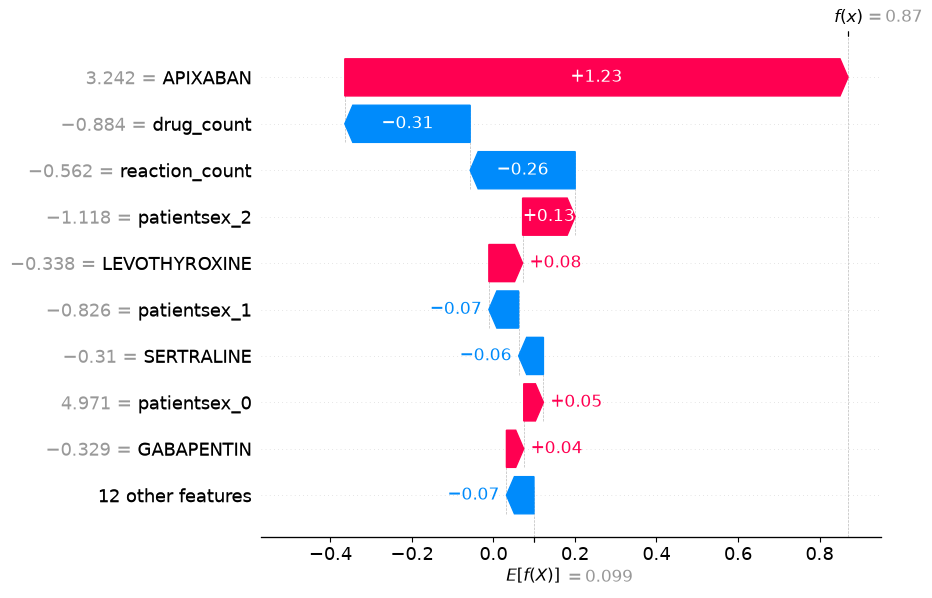

In [104]:
shap.plots.waterfall(shap_values[0])

### Explaining a Single Prediction

The waterfall plot above breaks down one specific report's prediction, starting from the baseline average prediction (E[f(X)] = 0.099) and showing how each feature moved it to the model's final output of 0.87 (a high predicted probability of "serious").

The largest single contributor is APIXABAN (+1.23). This report mentions Apixaban, which pushes the prediction sharply toward "serious." This matches the EDA finding that Apixaban had the highest serious-report rate of all 15 target drugs (92.3%). drug_count and reaction_count both pushed the prediction down slightly (-0.31, -0.26), since this particular report had relatively few drugs and reactions listed, but not enough to outweigh Apixaban's strong influence.

This single explanation independently corroborates two earlier findings — Apixaban's association with higher seriousness (from EDA), and the general direction of reaction_count/drug_count's influence (from the model's own learned coefficients), a third, per-prediction form of validation pointing the same direction as the other two.

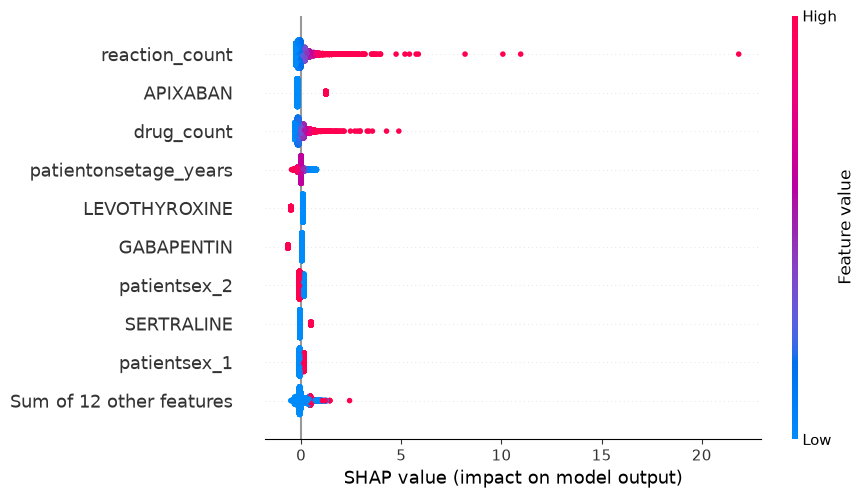

In [105]:
shap.plots.beeswarm(shap_values)

### Explaining Predictions Across the Whole Test Set

The beeswarm plot shows feature impact across every prediction, not just one example. Two clear patterns emerge:

**reaction_count and drug_count dominate overall.** Both show a wide, consistent spread of high (red) values pushing predictions strongly toward "serious," across a large number of reports, not an isolated pattern, but the model's most reliable, consistently-used signal. This matches both the EDA finding (reaction_count and drug_count showing real relationships with seriousness) and the model's own learned coefficients.

**Individual drug flags, including APIXABAN, matter far less overall than they appeared to in the single-report waterfall example.** In that earlier example, APIXABAN was the single largest contributor (+1.23) for one specific report. Here, across the whole test set, APIXABAN's typical impact is much smaller and more concentrated near zero. APIXABAN can only meaningfully influence a prediction for the minority of reports that actually mention it, whereas reaction_count and drug_count are present and informative on every single report. A single drug can be the dominant factor for one specific case while still being less influential than the numeric engineered features across the dataset as a whole.

**Patient age (patientonsetage_years) shows minimal impact across the board**, consistent with both the EDA finding and the earlier model coefficient of -0.009, a third independent confirmation of the same conclusion.

## Summary

SHAP confirms, what the EDA and the model's own learned coefficients already suggested, reaction_count and drug_count are the most reliable, consistently influential predictors of report seriousness, while patient age contributes little. 

Moreover, individual drug identity can matter for specific reports (as seen with Apixaban in the single-prediction example) but is less influential across the dataset as a whole than the two core engineered features.

This convergence across three different analytical approaches (visual EDA, model coefficients and SHAP explanations) gives confidence that reaction_count and drug_count are genuine, robust signals in this data, rather than artifacts of any one particular method.